##  Setup & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
DATA_DIR        = Path("Data")
EXPORT_DIR      = Path("Export")
END_DATE        = "2026-01-31"
DELAY_THRESHOLD = 5
WEATHER_CACHE   = DATA_DIR / "weather_toronto.csv"
EXPORT_PATH     = EXPORT_DIR / "bus_powerbi_1.csv"
EXPORT_MODEL    = EXPORT_DIR / "bus_model_export_1.csv"

## Loading Raw Data

Notice that the raw data consists of some inconsistencies between 2022-2024 and 2025+. The differences are noted below:

| | 2022-2024 XLSX | 2025+ CSV |
|---|---|---|
| Route | `Route` : integer (mostly) | `Line` : string e.g. "102 MARKHAM ROAD" |
| Location | `Location` : intersection name | `Station` : stop name |
| Incident type | `Incident` : plain English (15 categories) | `Code` : bus-specific code e.g. "EFO", "MFSH" |
| Direction | `Direction` : N/S/E/W + junk | `Bound` : N/S/E/W + junk |

ALso, the Code Descriptions file, `Bus Code Descriptions.csv` has a Windows-1252 encoding artefact: `â` should be read as `-` (em-dash corruption).

In [4]:
df_bus_codes = pd.read_csv(DATA_DIR / "Bus Code Descriptions.csv")
# Fix encoding artefact: the 3-character sequence U+00E2 U+0080 U+0093 is a
# double-encoded en-dash (–). We must replace all three chars together in one go
# replacing just the first char leaves two invisible control chars behind.
CORRUPT = "â"
df_bus_codes["DESCRIPTION"] = (
    df_bus_codes["DESCRIPTION"]
    .str.replace(CORRUPT, " - ", regex=False)
    .str.strip()
)
CODE_TO_DESC = dict(zip(df_bus_codes["CODE"], df_bus_codes["DESCRIPTION"]))
print(f"{len(df_bus_codes)} bus delay codes")
pd.set_option("display.max_rows", None)
print(df_bus_codes[["CODE","DESCRIPTION"]].to_string(index=False))

46 bus delay codes
 CODE                                   DESCRIPTION
  EFB                                          BODY
EFCAN                                  CANCELLATION
  EFD                                         DOORS
 EFDB                                   DISC BRAKES
 EFHV                                  HIGH VOLTAGE
EFHVA                              HEAT / VENT / AC
 EFLV                                   LOW VOLTAGE
  EFO                                         OTHER
  EFP                                    PROPULSION
 EFRA                                   RAMP ISSUES
  EFT                                        TRUCKS
 EFTB                                  TRACK BRAKES
 MFCN                                      CLEANING
 MFDV                                  ON DIVERSION
MFESA              NO OPERATOR AVAILABLE DUE TO ESA
 MFFD                                  FARE DISPUTE
 MFLD                                LABOUR DISPUTE
  MFO                                        

In [5]:
# loading xslx files (2022-2024)
print("Loading 2022-2024 XLSX files...")
xlsx_sources = [
    (DATA_DIR / "ttc-bus-delay-data-2022.xlsx", "2022"),
    (DATA_DIR / "ttc-bus-delay-data-2023.xlsx", "2023"),
    (DATA_DIR / "ttc-bus-delay-data-2024.xlsx", "2024"),
]
dfs_xlsx = [pd.read_excel(p, sheet_name=s) for p, s in xlsx_sources]
df_xlsx = pd.concat(dfs_xlsx, ignore_index=True)
print(f"  2022-2024 combined : {len(df_xlsx):,} rows")
print(f"  Columns : {df_xlsx.columns.tolist()}")
print(df_xlsx.head(3).to_string())

Loading 2022-2024 XLSX files...
  2022-2024 combined : 174,557 rows
  Columns : ['Date', 'Route', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction', 'Vehicle']
        Date Route   Time       Day                Location               Incident  Min Delay  Min Gap Direction  Vehicle
0 2022-01-01   320  02:00  Saturday        YONGE AND DUNDAS          General Delay          0        0       NaN     8531
1 2022-01-01   325  02:00  Saturday  OVERLEA AND THORCLIFFE              Diversion        131      161         W     8658
2 2022-01-01   320  02:00  Saturday       YONGE AND STEELES  Operations - Operator         17       20         S        0


In [6]:
# loading 2025+ csv file
df_csv = pd.read_csv(DATA_DIR / "TTC Bus Delay Data since 2025.csv")
df_csv = df_csv.drop(columns=["_id"], errors="ignore")
print(f"  2025+ rows : {len(df_csv):,} rows")
print(f"  Columns : {df_csv.columns.tolist()}")
print(df_csv.head(3).to_string())

  2025+ rows : 69,037 rows
  Columns : ['Date', 'Line', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Vehicle']
                  Date              Line   Time        Day            Station   Code  Min Delay  Min Gap Bound  Vehicle
0  2025-01-01T00:00:00  102 MARKHAM ROAD  02:15  Wednesday     WARDEN STATION  MFESA         20       40     N     3442
1  2025-01-01T00:00:00     65 PARLIAMENT  02:15  Wednesday    KIPLING STATION   MFUS          0        0   NaN        0
2  2025-01-01T00:00:00           64 MAIN  02:40  Wednesday  BROADVIEW STATION   MFUI          0        0   NaN     8546


## Data Normalization & Cleaning

### Approach
- Handling Route inconsistencies : extract leading integer from `Route`/`Line`; drop non-service rows (garage, training, RAD/OTC internal runs)
-  Column renaming : `Location` → `Stop`, `Station` → `Stop`, `Direction` → `Bound`
-  Code descriptions : merge 2025+ codes with `Bus Code Descriptions.csv` to get real `Description`. for 2022-2024, use `Incident` text directly
-  Typo / leaked-code handling : ~25 rows in the 2025+ CSV contain subway codes (MUIE, MUIS, SUDP, etc.) that don't belong in the bus dataset; treat as "Unknown"
-  Bound normalization : keep only {N, S, E, W}, null everything else
-  Broad category assignment : map descriptions → `Code_Category'

In [7]:
# Route is usually an integer but some rows have strings: "927 HIGHWAY 27", "RAD", "OTC"
# Extract the leading digits, rows without a numeric route are non-service.
df_xlsx["Route"] = (
    df_xlsx["Route"].astype(str).str.strip()
    .str.extract(r"^(\d+)", expand=False) # take only leading digits
    .astype(float) # converto to float since NaN can't exist in an int
)
n_before = len(df_xlsx)
df_xlsx = df_xlsx.dropna(subset=["Route"]).copy()
df_xlsx["Route"] = df_xlsx["Route"].astype(int)
print(f"2022-2024 — dropped {n_before - len(df_xlsx):,} non-service rows (RAD, OTC, etc.)")


2022-2024 — dropped 1,885 non-service rows (RAD, OTC, etc.)


In [8]:
# Rename to unified column names
df_xlsx = df_xlsx.rename(columns={"Location": "Stop", "Direction": "Bound"})

# For 2022-2024, Incident is the description. Code is unavailable.
# Description column = Incident text; Code column = None
df_xlsx["Code"]        = None
df_xlsx["Description"] = df_xlsx["Incident"]
df_xlsx["Line_Name"]   = None


In [9]:
# notice that there are some data leakeage between the bus data and subway data
# e.g "YU", "Line 1", etc.
# drop non-service Line values: "LINE 1 SHUTTLE", "RAD", "SRT", subway line names, etc.
NON_SERVICE_RE = (
    r"^LINE\b|^RAD\b|^SRT\b|^YU\b|^BD\b|^SHP\b"
    r"|^SHUTTLE\b|^FLEET\b|^TRAINING\b|^OTC\b|^A\b"
)
non_svc = df_csv["Line"].str.upper().str.contains(NON_SERVICE_RE, regex=True, na=False)
n_before = len(df_csv)
df_csv = df_csv[~non_svc].copy()
print(f"2025+ CSV — dropped {n_before - len(df_csv):,} non-service Line rows")

# extract route number: "102 MARKHAM ROAD" to 102
df_csv["Route"] = df_csv["Line"].str.extract(r"^(\d+)", expand=False).astype(float)
n_before = len(df_csv)
df_csv = df_csv.dropna(subset=["Route"]).copy()
df_csv["Route"] = df_csv["Route"].astype(int)
print(f"2025+ CSV — dropped {n_before - len(df_csv):,} further unresolvable rows")

# keeep the route name part for reference
df_csv["Line_Name"] = (
    df_csv["Line"].str.extract(r"^\d+\s+(.*)", expand=False).str.strip()
)

# rename Station to Stop
df_csv = df_csv.rename(columns={"Station": "Stop"})

2025+ CSV — dropped 244 non-service Line rows
2025+ CSV — dropped 851 further unresolvable rows


In [10]:
# merge bus code descriptions
# subway codes won't match the bus lookup and get Description = "Unknown".
df_csv["Description"] = df_csv["Code"].map(CODE_TO_DESC).fillna("Unknown")

unknown_cnt = (df_csv["Description"] == "Unknown").sum()
print(f"2025+ CSV — {unknown_cnt} rows with unrecognised codes (likely subway code leakage → 'Unknown')")
if unknown_cnt > 0:
    print("  Unrecognised codes:", df_csv.loc[df_csv["Description"]=="Unknown","Code"].value_counts().to_dict())

# for 2025+, derive Incident from Description (mirrors 2022-2024 Incident usage)
df_csv["Incident"] = df_csv["Description"]

# data concatenation
COMMON_COLS = ["Date", "Time", "Day", "Route", "Stop", "Line_Name",
               "Code", "Incident", "Description", "Min Delay", "Min Gap", "Bound", "Vehicle"]
df = pd.concat([df_xlsx[COMMON_COLS], df_csv[COMMON_COLS]], ignore_index=True)

print(f"Total shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range : {pd.to_datetime(df['Date']).min().date()} to {pd.to_datetime(df['Date']).max().date()}")

2025+ CSV — 22 rows with unrecognised codes (likely subway code leakage → 'Unknown')


  Unrecognised codes: {'MTDV': 3, 'TTPD': 3, 'MTO': 2, 'MTNOA': 2, 'MTSAN': 2, 'MUO': 2, 'SUDP': 1, 'MTVIS': 1, 'STO': 1, 'MUIS': 1, 'MTUS': 1, 'MUIE': 1, 'SRO': 1, 'ETO': 1}
Total shape : 240,614 rows x 13 columns
Date range : 2022-01-01 to 2026-01-31


In [11]:
# normalize Bounds / Direction values to N/S/E/W, set invalid values to None
VALID_BOUNDS = {"N", "S", "E", "W"}
df["Bound"] = df["Bound"].where(df["Bound"].isin(VALID_BOUNDS), other=None)
print(f"Bound distribution after normalization:")
print(df["Bound"].value_counts().to_string())
print(f"Bound null %: {df['Bound'].isna().mean():.1%}  (kept for Power BI, not used in model)")
print()

# assign code category
# works on both 2022-2024 Incident text and 2025+ Description text.

def assign_bus_category(text):
    t = str(text).lower()
    # Mechanical / Equipment
    if any(w in t for w in ["body", "door", "brake", "voltage", "propulsion",
                             "trucks", "ramp", "heat", "vent", "ac", "mechanical",
                             "collision - ttc"]):
        return "Mechanical"
    # Passenger / Medical
    if any(w in t for w in ["ill customer", "on board injury", "transported",
                             "transportation declined"]):
        return "Passenger / Medical"
    # Security / Safety
    if any(w in t for w in ["assault", "disorderly", "bomb", "police", "suspicious",
                             "security", "fare dispute", "investigation"]):
        return "Security / Safety"
    # Cleaning / Sanitary
    if any(w in t for w in ["cleaning", "unsanitary", "disinfection", "sanitary"]):
        return "Cleaning / Sanitary"
    # Emergency / Traffic / Collision
    if any(w in t for w in ["fire", "smoke", "collision", "personal injury",
                             "property damage", "emergency", "road blocked"]):
        return "Emergency / Traffic"
    # Operational Disruption (diversion, shuttle, parade, can't hold schedule)
    if any(w in t for w in ["diversion", "shuttle bus", "parade", "march",
                             "general delay", "held by", "cancellation"]):
        return "Operational Disruption"
    # Operations (operator, schedule, late, vision)
    if any(w in t for w in ["operator", "schedule", "late entering", "late vehicle",
                             "switch", "operations", "vision", "no operator available",
                             "utilized off route", "utilized off", "labour", "labor"]):
        return "Operations"
    # Weather
    if any(w in t for w in ["weather", "snow", "ice", "flood"]):
        return "Weather"
    return "Other"

df["Code_Category"] = df["Description"].apply(assign_bus_category)

print("Code_Category distribution:")
print(df["Code_Category"].value_counts().to_string())
print()
print(f"Final shape after unification: {df.shape[0]:,} rows x {df.shape[1]} columns")

Bound distribution after normalization:
Bound
N    55199
S    52714
E    47336
W    44280
Bound null %: 17.1%  (kept for Power BI, not used in model)

Code_Category distribution:
Code_Category
Mechanical                74698
Operations                69795
Operational Disruption    31476
Security / Safety         19230
Other                     17578
Emergency / Traffic       14620
Cleaning / Sanitary        7919
Passenger / Medical        4157
Weather                    1141

Final shape after unification: 240,614 rows x 14 columns


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240614 entries, 0 to 240613
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Date           240614 non-null  object
 1   Time           240614 non-null  str   
 2   Day            240614 non-null  str   
 3   Route          240614 non-null  int64 
 4   Stop           240613 non-null  str   
 5   Line_Name      67150 non-null   object
 6   Code           67942 non-null   object
 7   Incident       240614 non-null  str   
 8   Description    240614 non-null  str   
 9   Min Delay      240614 non-null  int64 
 10  Min Gap        240614 non-null  int64 
 11  Bound          199529 non-null  str   
 12  Vehicle        240614 non-null  int64 
 13  Code_Category  240614 non-null  str   
dtypes: int64(4), object(3), str(7)
memory usage: 25.7+ MB


In [13]:
df.head()

,Date,Time,Day,Route,Stop,Line_Name,Code,Incident,Description,Min Delay,Min Gap,Bound,Vehicle,Code_Category
0,2022-01-01 00:00:00,02:00,Saturday,320,YONGE AND DUNDAS,None,None,General Delay,General Delay,0,0,NaN,8531,Operational Disruption
1,2022-01-01 00:00:00,02:00,Saturday,325,OVERLEA AND THORCLIFFE,None,None,Diversion,Diversion,131,161,W,8658,Operational Disruption
2,2022-01-01 00:00:00,02:00,Saturday,320,YONGE AND STEELES,None,None,Operations - Operator,Operations - Operator,17,20,S,0,Operations
3,2022-01-01 00:00:00,02:07,Saturday,320,YONGE AND STEELES,None,None,Operations - Operator,Operations - Operator,4,11,S,0,Operations
4,2022-01-01 00:00:00,02:13,Saturday,320,YONGE AND STEELES,None,None,Operations - Operator,Operations - Operator,4,8,S,0,Operations


### Post Cleaning Summary
~240,000 bus delay incidents from **January 2022 to January 2026**, combining four source files:
- 3 XLSX files (2022, 2023, 2024)
- 1 CSV file (2025+)

| Concept | How to find it |
|---|---|
| **Bus route** | `Route` column : always a clean integer (e.g. `38`). This is the only consistent identifier across all years. |
| **Route name** | `Line_Name` column : e.g. `"HIGHLAND CREEK"`. **Only populated for 2025+ rows**; null for 2022–2024 because that data never included names. To get "38 Highland Creek", combine `Route` + `Line_Name`. |
| **Bus stop / intersection** | `Stop` column : the stop name or intersection (e.g. `"YONGE AND DUNDAS"`) |
| **What caused the delay** | `Description` column : plain English for all rows (e.g. `"DISORDERLY PATRON"`, `"DOORS"`, `"ON DIVERSION"`) |
| **Broad delay category** | `Code_Category` column : groups descriptions into ~8 buckets: Mechanical, Security/Safety, Operational Disruption, etc. **Fully populated for all 240K rows across all years.** |
| **Raw bus code** | `Code` column : the official code abbreviation (e.g. `"SFDP"`, `"EFD"`). **Only populated for 2025+ rows**; null for 2022–2024 because those years used plain-text incidents instead. |
| **Direction** | `Bound` : N/S/E/W only. ~17% null (invalid values like "NB", "SB" were nulled out). |



## Datetime Parsing & Time Features

In [14]:
df["Date_str"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")
df["Time_str"] = df["Time"].astype(str).str.strip().str[:5]

df["Datetime"] = pd.to_datetime(
    df["Date_str"] + " " + df["Time_str"],
    format="%Y-%m-%d %H:%M",
    errors="coerce",
)
n_bad = df["Datetime"].isna().sum()
if n_bad:
    print(f"Dropping {n_bad} rows with unparseable datetime")
    df = df.dropna(subset=["Datetime"]).copy()

df["Year"]      = df["Datetime"].dt.year
df["Month"]     = df["Datetime"].dt.month
df["Day_Num"]   = df["Datetime"].dt.day
df["Hour"]      = df["Datetime"].dt.hour
df["Weekday"]   = df["Datetime"].dt.weekday
df["DayName"]   = df["Datetime"].dt.day_name()
df["Peak_Hour"] = df["Hour"].apply(lambda x: 1 if (7 <= x <= 10) or (16 <= x <= 19) else 0)
df["Weekend"]   = (df["Weekday"] >= 5).astype(int)
df["Season"]    = df["Month"].map({
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Spring",  4:"Spring", 5:"Spring",
    6:"Summer",  7:"Summer", 8:"Summer",
    9:"Fall",   10:"Fall",  11:"Fall",
})
df = df.drop(columns=["Date_str", "Time_str"])

print(f"Final shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range  : {df['Datetime'].min().date()} to {df['Datetime'].max().date()}")
print()
print("Min Delay distribution:")
print(df["Min Delay"].describe().round(2).to_string())

Final shape : 240,614 rows x 24 columns
Date range  : 2022-01-01 to 2026-01-31

Min Delay distribution:
count    240614.00
mean         20.78
std          51.34
min           0.00
25%           8.00
50%          11.00
75%          20.00
max         999.00


## EDA

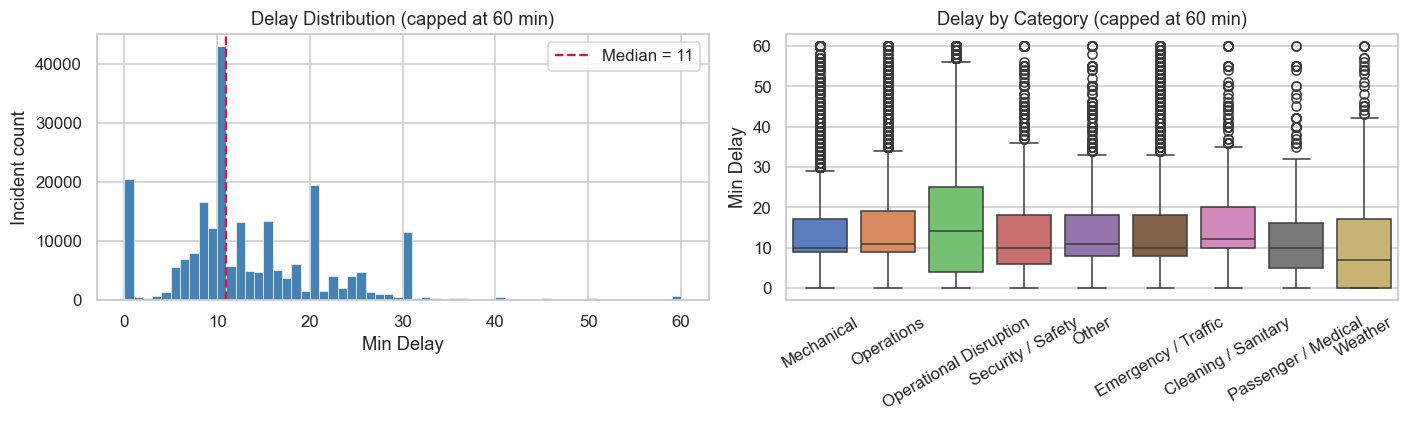

Rows with zero delay  : 8.5%
Rows delayed >= 5 min : 90.4%
Max single delay      : 999 min (16.6 hours)


In [15]:
# delay distribution and category boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_plot = df[df["Min Delay"] <= 60]
axes[0].hist(df_plot["Min Delay"], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Min Delay")
axes[0].set_ylabel("Incident count")
axes[0].set_title("Delay Distribution (capped at 60 min)")
axes[0].axvline(df["Min Delay"].median(), color="crimson", linestyle="--",
                label=f"Median = {df['Min Delay'].median():.0f}")
axes[0].legend()

cat_order = df["Code_Category"].value_counts().index.tolist()
sns.boxplot(data=df[df["Min Delay"] <= 60], x="Code_Category", y="Min Delay",
            order=cat_order, ax=axes[1], palette="muted")
axes[1].set_title("Delay by Category (capped at 60 min)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"Rows with zero delay  : {(df['Min Delay'] == 0).mean():.1%}")
print(f"Rows delayed >= 5 min : {(df['Min Delay'] >= 5).mean():.1%}")
print(f"Max single delay      : {df['Min Delay'].max()} min ({df['Min Delay'].max()/60:.1f} hours)")

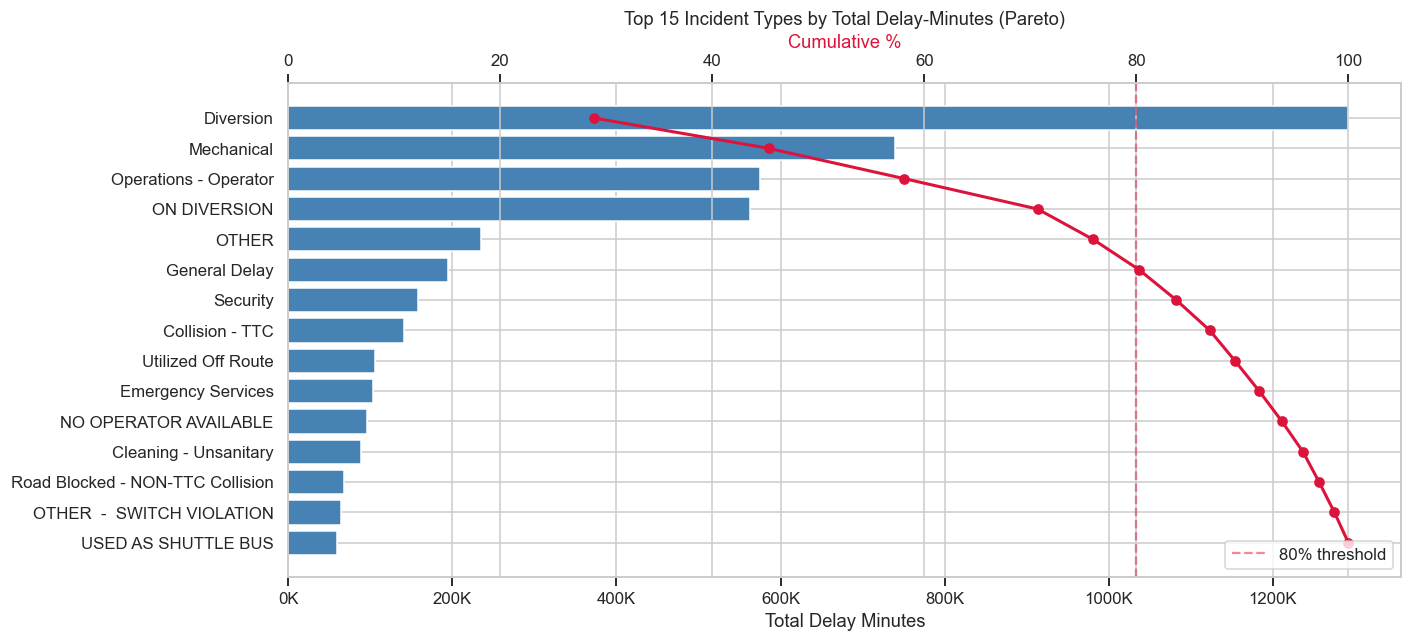

Top 3 incident types account for 52.1% of all delay-minutes


In [16]:
# top incidents - pareto chart
top_inc = (
    df[df["Min Delay"] > 0]
    .groupby("Description")["Min Delay"]
    .sum().reset_index()
    .sort_values("Min Delay", ascending=False)
    .head(15)
)
top_inc["Cumulative %"] = top_inc["Min Delay"].cumsum() / top_inc["Min Delay"].sum() * 100

fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.barh(top_inc["Description"][::-1], top_inc["Min Delay"][::-1], color="steelblue")
ax1.set_xlabel("Total Delay Minutes")
ax1.set_title("Top 15 Incident Types by Total Delay-Minutes (Pareto)")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

ax2 = ax1.twiny()
ax2.plot(top_inc["Cumulative %"][::-1], range(len(top_inc)), "o-", color="crimson", linewidth=2)
ax2.set_xlabel("Cumulative %", color="crimson")
ax2.set_xlim(0, 105)
ax2.axvline(80, color="crimson", linestyle="--", alpha=0.5, label="80% threshold")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

top3_pct = top_inc["Min Delay"].head(3).sum() / df["Min Delay"].sum() * 100
print(f"Top 3 incident types account for {top3_pct:.1f}% of all delay-minutes")

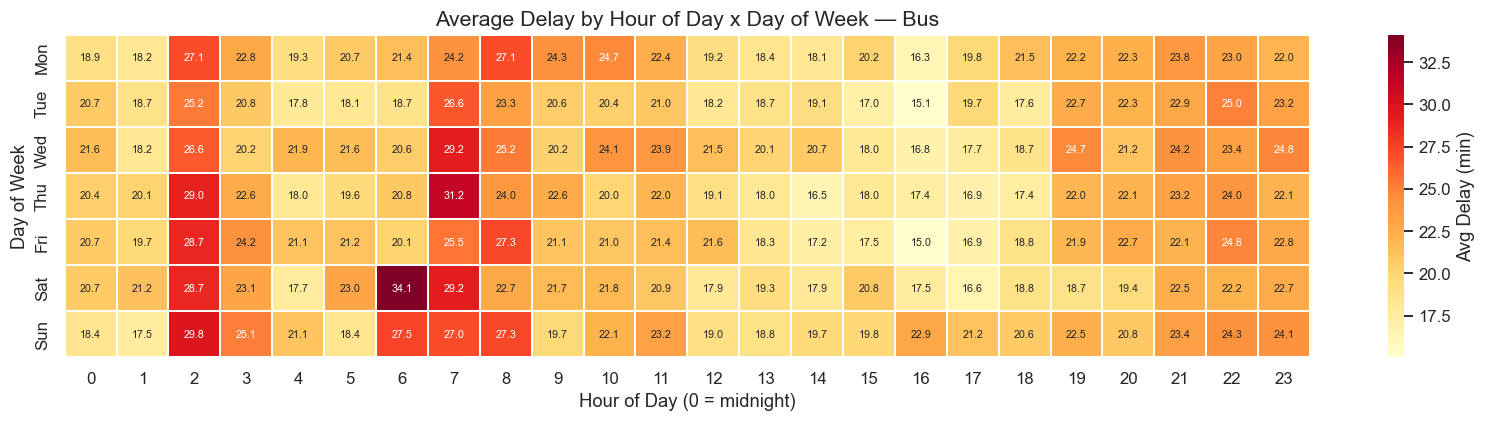

In [17]:
# hour x weekday heatmap
pivot = (
    df.groupby(["Weekday", "Hour"])["Min Delay"]
    .mean().reset_index()
    .pivot(index="Weekday", columns="Hour", values="Min Delay")
)
pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd", linewidths=0.3,
    cbar_kws={"label": "Avg Delay (min)"},
    annot=True, fmt=".1f", annot_kws={"size": 7}
)
ax.set_title("Average Delay by Hour of Day x Day of Week — Bus", fontsize=14)
ax.set_xlabel("Hour of Day (0 = midnight)")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.show()

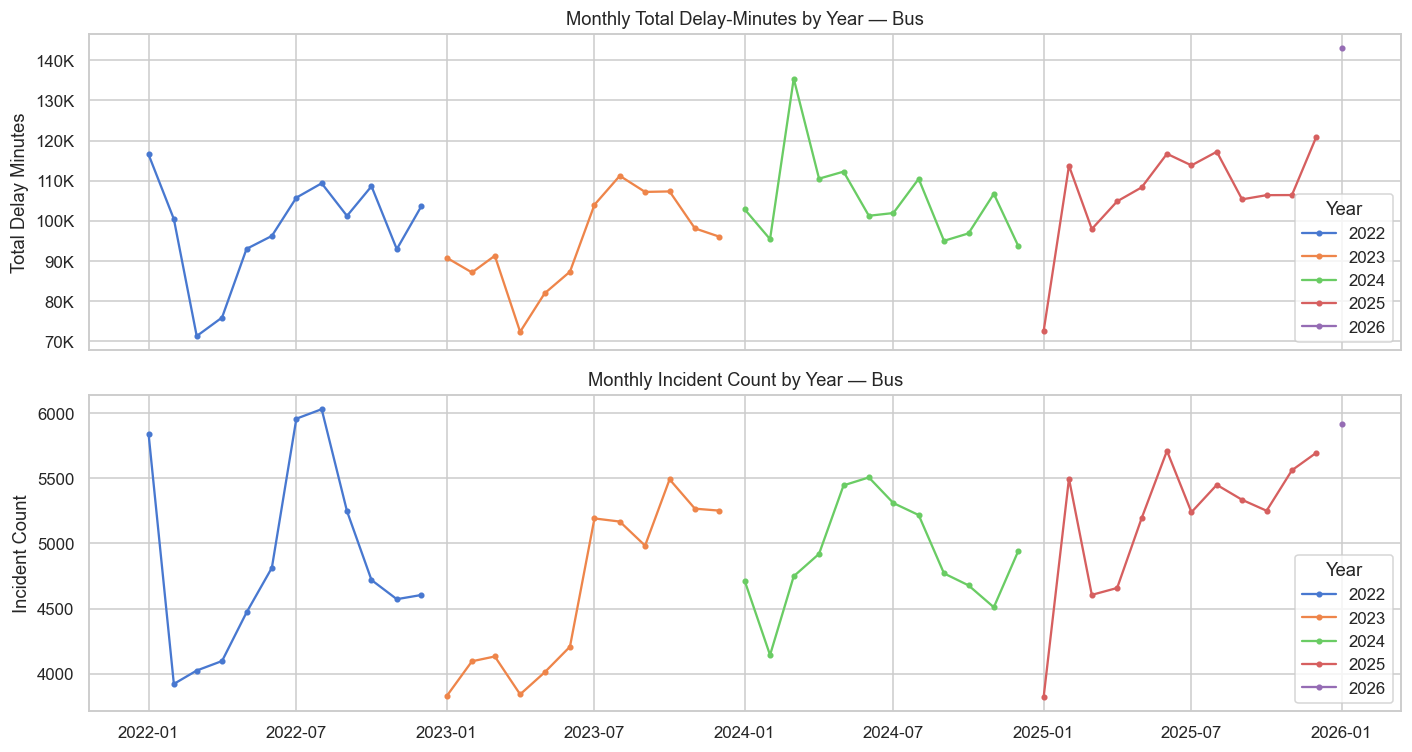

In [18]:
# year-over-year monthly trend
monthly = (
    df.groupby(["Year", "Month"])
    .agg(Total_Delay=("Min Delay", "sum"), Incidents=("Min Delay", "count"))
    .reset_index()
)
monthly["YearMonth"] = pd.to_datetime(
    monthly["Year"].astype(str) + "-" + monthly["Month"].astype(str).str.zfill(2) + "-01"
)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for yr, grp in monthly.groupby("Year"):
    axes[0].plot(grp["YearMonth"], grp["Total_Delay"], marker="o", markersize=3, label=str(yr))
axes[0].set_ylabel("Total Delay Minutes")
axes[0].set_title("Monthly Total Delay-Minutes by Year — Bus")
axes[0].legend(title="Year")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

for yr, grp in monthly.groupby("Year"):
    axes[1].plot(grp["YearMonth"], grp["Incidents"], marker="o", markersize=3, label=str(yr))
axes[1].set_ylabel("Incident Count")
axes[1].set_title("Monthly Incident Count by Year — Bus")
axes[1].legend(title="Year")

plt.tight_layout()
plt.show()

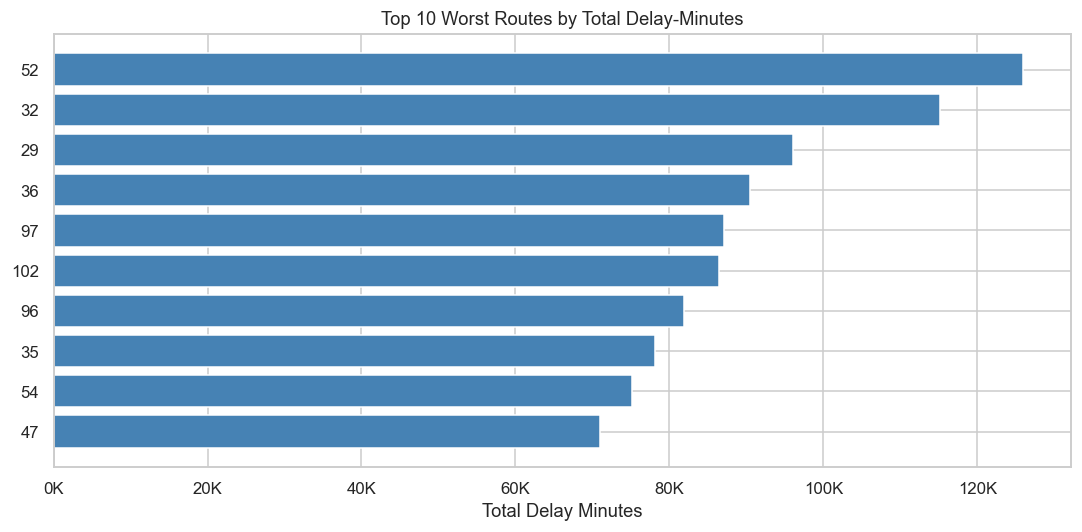

 Route  Total_Delay_Min  Incident_Count  Avg_Delay
    52           125908            6071       20.7
    32           115146            6916       16.6
    29            96012            4884       19.7
    36            90463            5958       15.2
    97            87020            1813       48.0
   102            86388            3899       22.2
    96            81940            3229       25.4
    35            78167            4658       16.8
    54            75184            4095       18.4
    47            70925            3244       21.9


In [19]:
# worst routes by total minutes
route_stats = (
    df[df["Min Delay"] > 0]
    .groupby("Route")
    .agg(
        Total_Delay_Min=("Min Delay", "sum"),
        Incident_Count=("Min Delay", "count"),
        Avg_Delay=("Min Delay", "mean"),
    )
    .reset_index()
    .sort_values("Total_Delay_Min", ascending=False)
    .head(10)
)
route_stats["Avg_Delay"] = route_stats["Avg_Delay"].round(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(route_stats["Route"].astype(str)[::-1], route_stats["Total_Delay_Min"][::-1], color="steelblue")
ax.set_xlabel("Total Delay Minutes")
ax.set_title("Top 10 Worst Routes by Total Delay-Minutes")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout()
plt.show()

print(route_stats[["Route","Total_Delay_Min","Incident_Count","Avg_Delay"]].to_string(index=False))

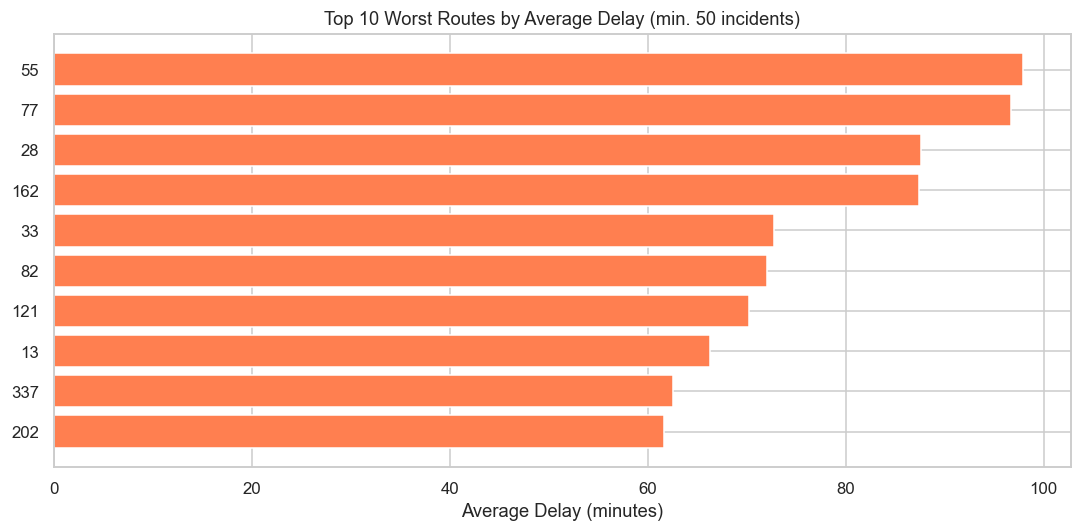

 Route  Avg_Delay  Incident_Count  Total_Delay_Min
    55       97.9             217            21248
    77       96.7             297            28710
    28       87.6             114             9984
   162       87.4             294            25698
    33       72.8             282            20536
    82       72.1             183            13203
   121       70.2             819            57528
    13       66.3             577            38277
   337       62.6              68             4257
   202       61.7             160             9867


In [20]:
# worst routes by average delay (min 50 incidents)
MIN_INCIDENTS = 50

route_avg = (
    df[df["Min Delay"] > 0]
    .groupby("Route")
    .agg(
        Total_Delay_Min=("Min Delay", "sum"),
        Incident_Count=("Min Delay", "count"),
        Avg_Delay=("Min Delay", "mean"),
    )
    .reset_index()
)
route_avg["Avg_Delay"] = route_avg["Avg_Delay"].round(1)
route_avg_filtered = (
    route_avg[route_avg["Incident_Count"] >= MIN_INCIDENTS]
    .sort_values("Avg_Delay", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(route_avg_filtered["Route"].astype(str)[::-1],
        route_avg_filtered["Avg_Delay"][::-1], color="coral")
ax.set_xlabel("Average Delay (minutes)")
ax.set_title(f"Top 10 Worst Routes by Average Delay (min. {MIN_INCIDENTS} incidents)")
plt.tight_layout()
plt.show()

print(route_avg_filtered[["Route","Avg_Delay","Incident_Count","Total_Delay_Min"]].to_string(index=False))

## EDA Summary

### Delay Distribution
The distribution of `Min Delay` is very right skewed, consistent with transit delay data in general:

| Statistic | Value |
|---|---|
| % of incidents with zero delay | 8.5% |
| % of incidents with ≥ 5 min delay | 90.4% |
| Median delay | 11.0 min |
| Mean delay | 20.8 min |
| 75th percentile | 20 min |
| 95th percentile | 42 min |
| Maximum recorded delay | 999 min |

The large gap between the median (11 min) and mean (20.8 min) shows severe incidents pulling the average up. The majority of delays are moderate, but a small number of extreme events contribute disproportionately to total lost time.

Also note that (before outlier removal) the max Min Delay is ~999 minutes, which skews the distribution. Keep it in mind that it is not the case that these types of incidents happen regularly.

### Incident Categories
Incidents are grouped into 8 broad categories derived from the `Description` field:

| Category | Incidents | Share |
|---|---|---|
| Operations | 69,795 | 29.0% |
| Mechanical | 63,417 / 74,698* | 26.4% / 31.1%* |
| Operational Disruption | 31,476 | 13.1% |
| Emergency / Traffic | 25,901 | 10.8% |
| Security / Safety | 19,230 | 8.0% |
| Other | 17,578 | 7.3% |
| Cleaning / Sanitary | 7,919 | 3.3% |
| Passenger / Medical | 4,157 | 1.7% |
| Weather | 1,141 | 0.5% |

**Operations** (operator availability, scheduling, late vehicles) and **Mechanical** (equipment failures) together account for over **55%** of all incidents, making fleet reliability and operator management the two most critical pressure points in the system.

### Year-over-Year Trends

| Year | Incidents | Total Delay (min) | Avg Delay / Incident |
|---|---|---|---|
| 2022 | 58,301 | 1,175,292 | 20.2 min |
| 2023 | 55,466 | 1,135,136 | 20.5 min |
| 2024 | 58,905 | 1,262,674 | 21.4 min |
| 2025 | 62,021 | 1,284,498 | 20.7 min |
| 2026 *(Jan only)* | 5,921 | 142,988 | 24.2 min |

Incident volume has been gradually **rising** from 2022 to 2025 (+6.4% over three full years), while average severity per incident has remained relatively stable around 20–21 minutes. As a result, **total delay-minutes lost per year has grown**, reaching over **1.28 million minutes in 2025**. The 2026 figure reflects only one month of data and should not be compared directly to full-year figures.



## Weather Data Integration

In [ ]:

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude" : 43.6532,
    "longitude": -79.3832,
    "start_date": "2022-01-01",
    "end_date"  : END_DATE,
    "hourly"    : "temperature_2m,precipitation,rain,snowfall,snow_depth,wind_speed_10m,weather_code",
    "timezone"  : "America/Toronto",
}
resp = requests.get(url, params=params, timeout=90)
resp.raise_for_status()
df_weather = pd.DataFrame(resp.json()["hourly"])
df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather.to_csv(WEATHER_CACHE, index=False)
print(f"Fetched and cached: {len(df_weather):,} rows")

print(f"Weather range: {df_weather['time'].min().date()} to {df_weather['time'].max().date()}")
df_weather.head(3)

In [22]:
df["hour_floor"] = df["Datetime"].dt.floor("h")
df = df.merge(
    df_weather.rename(columns={"time": "hour_floor"}),
    on="hour_floor", how="left",
)
print(f"Weather merge coverage: {df['temperature_2m'].notna().mean():.1%}")
df = df.drop(columns=["hour_floor"])

Weather merge coverage: 100.0%


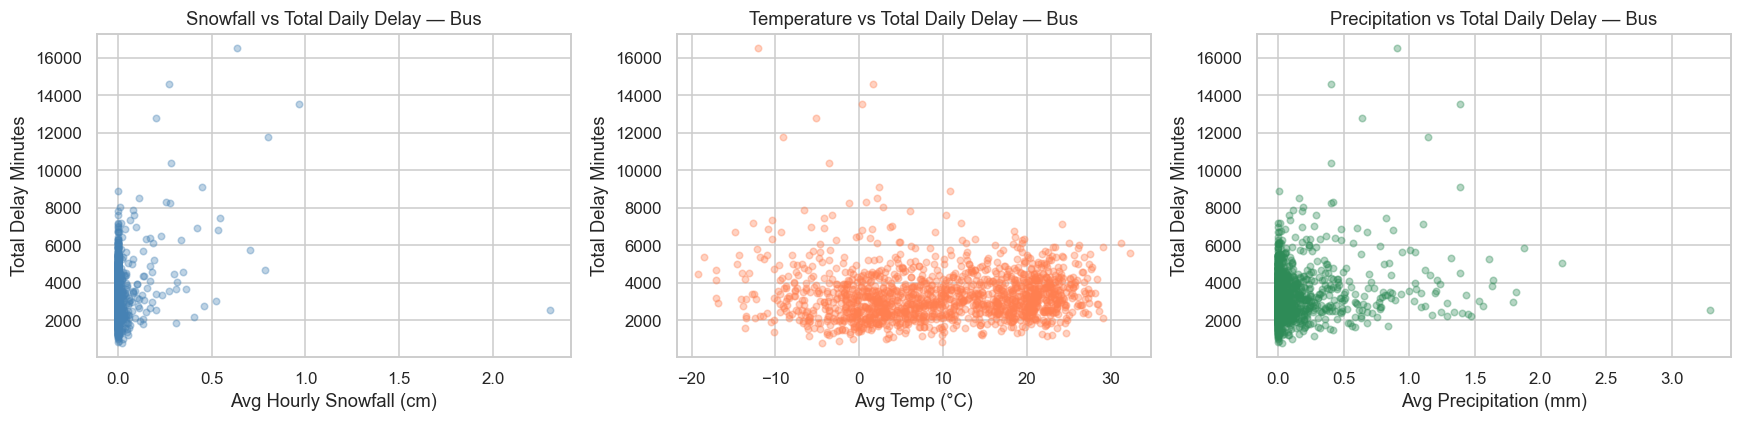

Snow days   :    9 — avg total delay 8023 min
Normal days : 1483 — avg total delay 3323 min
Delta       : +4700 min on snow days


In [23]:
df_daily = (
    df.groupby(df["Datetime"].dt.date)
    .agg(
        Total_Delay_Min=("Min Delay", "sum"),
        Avg_Snowfall=("snowfall", "mean"),
        Avg_Temp=("temperature_2m", "mean"),
        Avg_Precip=("precipitation", "mean"),
    )
    .reset_index()
    .rename(columns={"Datetime": "Date"})
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(df_daily["Avg_Snowfall"], df_daily["Total_Delay_Min"], alpha=0.35, color="steelblue", s=18)
axes[0].set_xlabel("Avg Hourly Snowfall (cm)"); axes[0].set_ylabel("Total Delay Minutes")
axes[0].set_title("Snowfall vs Total Daily Delay — Bus")

axes[1].scatter(df_daily["Avg_Temp"], df_daily["Total_Delay_Min"], alpha=0.35, color="coral", s=18)
axes[1].set_xlabel("Avg Temp (°C)"); axes[1].set_ylabel("Total Delay Minutes")
axes[1].set_title("Temperature vs Total Daily Delay — Bus")

axes[2].scatter(df_daily["Avg_Precip"], df_daily["Total_Delay_Min"], alpha=0.35, color="seagreen", s=18)
axes[2].set_xlabel("Avg Precipitation (mm)"); axes[2].set_ylabel("Total Delay Minutes")
axes[2].set_title("Precipitation vs Total Daily Delay — Bus")

plt.tight_layout()
plt.show()

snow_days   = df_daily[df_daily["Avg_Snowfall"] > 0.5]
normal_days = df_daily[df_daily["Avg_Snowfall"] <= 0.5]
print(f"Snow days   : {len(snow_days):>4} — avg total delay {snow_days['Total_Delay_Min'].mean():.0f} min")
print(f"Normal days : {len(normal_days):>4} — avg total delay {normal_days['Total_Delay_Min'].mean():.0f} min")
print(f"Delta       : +{snow_days['Total_Delay_Min'].mean() - normal_days['Total_Delay_Min'].mean():.0f} min on snow days")

## Feature Engineering

In [24]:
df = df.sort_values("Datetime").reset_index(drop=True)

df["Previous_Delay"] = df["Min Delay"].shift(1)

df["Rolling_Delay_5"] = (
    df["Min Delay"].shift(1).rolling(window=5, min_periods=1).mean()
)

df["Hist_Avg_Route_Hour"] = (
    df.groupby(["Route", "Hour"])["Min Delay"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

print("Engineered features added:")
print(df[["Datetime","Route","Hour","Min Delay",
          "Previous_Delay","Rolling_Delay_5","Hist_Avg_Route_Hour"]].head(10).to_string())

Engineered features added:
             Datetime  Route  Hour  Min Delay  Previous_Delay  Rolling_Delay_5  Hist_Avg_Route_Hour
0 2022-01-01 00:28:00     85     0         22             NaN              NaN                  NaN
1 2022-01-01 00:57:00     70     0         15            22.0        22.000000                  NaN
2 2022-01-01 01:03:00     47     1         10            15.0        18.500000                  NaN
3 2022-01-01 01:12:00    131     1         25            10.0        15.666667                  NaN
4 2022-01-01 01:32:00     20     1         15            25.0        18.000000                  NaN
5 2022-01-01 01:35:00     17     1         18            15.0        17.400000                  NaN
6 2022-01-01 01:48:00    102     1         30            18.0        16.600000                  NaN
7 2022-01-01 02:00:00    320     2          0            30.0        19.600000                  NaN
8 2022-01-01 02:00:00    320     2         17             0.0        17.6

In [25]:
df.head()

,Date,Time,Day,Route,Stop,Line_Name,Code,Incident,Description,Min Delay,Min Gap,Bound,Vehicle,Code_Category,Datetime,Year,Month,Day_Num,Hour,Weekday,DayName,Peak_Hour,Weekend,Season,temperature_2m,precipitation,rain,snowfall,snow_depth,wind_speed_10m,weather_code,Previous_Delay,Rolling_Delay_5,Hist_Avg_Route_Hour
0,2022-01-01 00:00:00,00:28,Saturday,85,DON MILLS STATION,None,None,Operations - Operator,Operations - Operator,22,42,E,9076,Operations,2022-01-01 00:28:00,2022,1,1,0,5,Saturday,0,1,Winter,3.8,0.0,0.0,0.0,0.02,9.1,3,NaN,NaN,NaN
1,2022-01-01 00:00:00,00:57,Saturday,70,COXWELL STATION,None,None,Utilized Off Route,Utilized Off Route,15,30,W,8435,Operations,2022-01-01 00:57:00,2022,1,1,0,5,Saturday,0,1,Winter,3.8,0.0,0.0,0.0,0.02,9.1,3,22.0,22.000000,NaN
2,2022-01-01 00:00:00,01:03,Saturday,47,ST CLAIR AND LANDOWNE,None,None,Collision - TTC,Collision - TTC,10,25,W,8104,Mechanical,2022-01-01 01:03:00,2022,1,1,1,5,Saturday,0,1,Winter,3.3,0.0,0.0,0.0,0.02,5.1,3,15.0,18.500000,NaN
3,2022-01-01 00:00:00,01:12,Saturday,131,SCARBOROUGH CENTRE CEN,None,None,General Delay,General Delay,25,47,NaN,0,Operational Disruption,2022-01-01 01:12:00,2022,1,1,1,5,Saturday,0,1,Winter,3.3,0.0,0.0,0.0,0.02,5.1,3,10.0,15.666667,NaN
4,2022-01-01 00:00:00,01:32,Saturday,20,MAIN STATION,None,None,Operations - Operator,Operations - Operator,15,15,N,8488,Operations,2022-01-01 01:32:00,2022,1,1,1,5,Saturday,0,1,Winter,3.3,0.0,0.0,0.0,0.02,5.1,3,25.0,18.000000,NaN


## Export for Power BI

In [27]:
EXPORT_COLS = [
    "Datetime", "Date", "Time", "Year", "Month", "Day_Num",
    "Hour", "Weekday", "DayName", "Season", "Peak_Hour", "Weekend",
    "Route", "Stop", "Line_Name", "Bound",
    "Code", "Description", "Code_Category",
    "Min Delay", "Min Gap",
    "temperature_2m", "precipitation", "rain", "snowfall",
    "snow_depth", "wind_speed_10m", "weather_code",
]

# Some diversions and event-day incidents have 900-999 min delays (real but
# rare). Including them in Power BI will massively skew route averages,  e.g.
# Route 77 avg goes from 16 min to 89 min with outliers included.
# We add a flag so Power BI can exclude them by default while keeping the raw data.
Q1 = df["Min Delay"].quantile(0.25)
Q3 = df["Min Delay"].quantile(0.75)
IQR_val = Q3 - Q1
outlier_fence = Q3 + 3 * IQR_val
df["Is_Outlier"] = (df["Min Delay"] > outlier_fence).astype(int)

n_outliers = df["Is_Outlier"].sum()

export_cols_present = [c for c in EXPORT_COLS if c in df.columns] + ["Is_Outlier"]
df_export = df[export_cols_present].copy()

df_export.to_csv(EXPORT_PATH, index=False)
print(f"Columns : {df_export.columns.tolist()}")

Columns : ['Datetime', 'Date', 'Time', 'Year', 'Month', 'Day_Num', 'Hour', 'Weekday', 'DayName', 'Season', 'Peak_Hour', 'Weekend', 'Route', 'Stop', 'Line_Name', 'Bound', 'Code', 'Description', 'Code_Category', 'Min Delay', 'Min Gap', 'temperature_2m', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'wind_speed_10m', 'weather_code', 'Is_Outlier']


## Predictive Modelling with XGBoost Classification